# IBM RH Análise de Atrito & Performance de Funcionários

## Análise Exploratória e Tratamentos de Dados

In [1]:
#Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import joblib
import os

#Arquivos auxiliares src
from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
    RANDOM_STATE
)
from src.graficos import plot_comparar_metricas_modelos, plot_coeficientes
#Configurações
pd.set_option('display.max_columns', None)

#Skitlearing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
#dummy
from sklearn.dummy import DummyClassifier
#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(palette = 'bright')


In [38]:
df= pd.read_parquet(DADOS_TRATADOS)
df.head()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,AreaDeFormacao,AvaliacaoDeDesempenho,Cargo,Departamento,Desligamento,DistanciaDeCasa,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,EstadoCivil,Genero,HoraExtra,Idade,NivelDeOpcoesDeAcoes,NivelDoCargo,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,ViagemDeNegocios
0,5,0,6,4,Ciências Biológicas,3,Executivo de Vendas,Vendas,Sim,1,3,1,2,Solteiro(a),Feminino,Sim,41,0,2,8,11,5993,2,4,1,1102,94,19479,8,0,Viaja Raramente
1,7,1,10,7,Ciências Biológicas,4,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,8,2,3,1,Casado(a),Masculino,Não,49,1,2,1,23,5130,3,2,4,279,61,24907,10,3,Viaja Frequentemente
2,0,0,0,0,Outros,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Sim,2,2,3,2,Solteiro(a),Masculino,Sim,37,0,1,6,15,2090,4,3,2,1373,92,2396,7,3,Viaja Raramente
3,0,3,8,7,Ciências Biológicas,3,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,3,3,3,4,Casado(a),Feminino,Sim,33,0,1,1,11,2909,4,3,3,1392,56,23159,8,3,Viaja Frequentemente
4,2,2,2,2,Medicina,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Não,2,3,3,1,Casado(a),Masculino,Não,27,1,1,9,12,3468,1,2,4,591,40,16632,6,3,Viaja Raramente


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   AnosComGerenteAtual           1470 non-null   int8    
 1   AnosDesdeAUltimaPromocao      1470 non-null   int8    
 2   AnosNaEmpresa                 1470 non-null   int8    
 3   AnosNoCargoAtual              1470 non-null   int8    
 4   AreaDeFormacao                1470 non-null   str     
 5   AvaliacaoDeDesempenho         1470 non-null   int8    
 6   Cargo                         1470 non-null   str     
 7   Departamento                  1470 non-null   str     
 8   Desligamento                  1470 non-null   str     
 9   DistanciaDeCasa               1470 non-null   int8    
 10  EnvolvimentoNoTrabalho        1470 non-null   int8    
 11  EquilibrioVidaTrabalho        1470 non-null   int8    
 12  Escolaridade                  1470 non-null   int8    
 13 

In [40]:
df.describe()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,AvaliacaoDeDesempenho,DistanciaDeCasa,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,Idade,NivelDeOpcoesDeAcoes,NivelDoCargo,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,4.123129,2.187755,7.008163,4.229252,3.153741,9.192517,2.729932,2.761224,2.912925,36.923810,0.793878,2.063946,2.693197,15.209524,6502.931293,2.721769,2.728571,2.712245,802.485714,65.891156,14313.103401,11.279592,2.799320
std,3.568136,3.222430,6.126525,3.623137,0.360824,8.106864,0.711561,0.706476,1.024165,9.135373,0.852077,1.106940,2.498009,3.659938,4707.956783,1.093082,1.102846,1.081209,403.509100,20.329428,7117.786044,7.780782,1.289271
min,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,11.000000,1009.000000,1.000000,1.000000,1.000000,102.000000,30.000000,2094.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,30.000000,0.000000,1.000000,1.000000,12.000000,2911.000000,2.000000,2.000000,2.000000,465.000000,48.000000,8047.000000,6.000000,2.000000
50%,3.000000,1.000000,5.000000,3.000000,3.000000,7.000000,3.000000,3.000000,3.000000,36.000000,1.000000,2.000000,2.000000,14.000000,4919.000000,3.000000,3.000000,3.000000,802.000000,66.000000,14235.500000,10.000000,3.000000
75%,7.000000,3.000000,9.000000,7.000000,3.000000,14.000000,3.000000,3.000000,4.000000,43.000000,1.000000,3.000000,4.000000,18.000000,8379.000000,4.000000,4.000000,4.000000,1157.000000,83.750000,20461.500000,15.000000,3.000000
max,17.000000,15.000000,40.000000,18.000000,4.000000,29.000000,4.000000,4.000000,5.000000,60.000000,3.000000,5.000000,9.000000,25.000000,19999.000000,4.000000,4.000000,4.000000,1499.000000,100.000000,26999.000000,40.000000,6.000000


In [41]:
df.describe(exclude='number')

,AreaDeFormacao,Cargo,Departamento,Desligamento,EstadoCivil,Genero,HoraExtra,ViagemDeNegocios
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,6,9,3,2,3,2,2,3
top,Ciências Biológicas,Executivo de Vendas,Pesquisa e Desenvolvimento,Não,Casado(a),Masculino,Não,Viaja Raramente
freq,606,326,961,1233,673,882,1054,1043


In [42]:
coluna_alvo = ['Desligamento']
print(f"Coluna alvo: {coluna_alvo}")

#colunas ordenadas
colunas_categoricas_ordenadas = [
    'AvaliacaoDeDesempenho', 
    'EnvolvimentoNoTrabalho',
    'EquilibrioVidaTrabalho',
    'Escolaridade',
    'NivelDoCargo',
    'SatisfacaoComAmbiente',
    'SatisfacaoComOTrabalho',
    'SatisfacaoComRelacionamentos', 
    'ViagemDeNegocios',
    'NivelDeOpcoesDeAcoes'
    ]
print(f"Colunas categóricas ordenadas: {colunas_categoricas_ordenadas}")

#colunas categoricas
colunas_categoricas = df.select_dtypes(include='str').columns.tolist()
colunas_categoricas.remove(coluna_alvo[0])
colunas_categoricas = [col for col in colunas_categoricas if col not in colunas_categoricas_ordenadas]
print(f"Colunas categóricas: {colunas_categoricas}")

#colunas numéricas
colunas_numericas = [col for col in df.columns if col not in (colunas_categoricas_ordenadas+colunas_categoricas+coluna_alvo)]
print(f"Colunas numéricas: {colunas_numericas}")


Coluna alvo: ['Desligamento']
Colunas categóricas ordenadas: ['AvaliacaoDeDesempenho', 'EnvolvimentoNoTrabalho', 'EquilibrioVidaTrabalho', 'Escolaridade', 'NivelDoCargo', 'SatisfacaoComAmbiente', 'SatisfacaoComOTrabalho', 'SatisfacaoComRelacionamentos', 'ViagemDeNegocios', 'NivelDeOpcoesDeAcoes']
Colunas categóricas: ['AreaDeFormacao', 'Cargo', 'Departamento', 'EstadoCivil', 'Genero', 'HoraExtra']
Colunas numéricas: ['AnosComGerenteAtual', 'AnosDesdeAUltimaPromocao', 'AnosNaEmpresa', 'AnosNoCargoAtual', 'DistanciaDeCasa', 'Idade', 'NumeroDeEmpresasQueTrabalhou', 'PercentualDeAumentoSalarial', 'RendaMensal', 'TaxaDiaria', 'TaxaHoraria', 'TaxaMensal', 'TotalDeAnosTrabalhados', 'TreinamentosNoAnoPassado']


In [43]:
df[colunas_categoricas_ordenadas].head()

,AvaliacaoDeDesempenho,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,NivelDoCargo,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,ViagemDeNegocios,NivelDeOpcoesDeAcoes
0,3,3,1,2,2,2,4,1,Viaja Raramente,0
1,4,2,3,1,2,3,2,4,Viaja Frequentemente,1
2,3,2,3,2,1,4,3,2,Viaja Raramente,0
3,3,3,3,4,1,4,3,3,Viaja Frequentemente,0
4,3,3,3,1,1,1,2,4,Viaja Raramente,1


In [44]:
df[colunas_categoricas].head()

,AreaDeFormacao,Cargo,Departamento,EstadoCivil,Genero,HoraExtra
0,Ciências Biológicas,Executivo de Vendas,Vendas,Solteiro(a),Feminino,Sim
1,Ciências Biológicas,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Casado(a),Masculino,Não
2,Outros,Técnico de Laboratório,Pesquisa e Desenvolvimento,Solteiro(a),Masculino,Sim
3,Ciências Biológicas,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Casado(a),Feminino,Sim
4,Medicina,Técnico de Laboratório,Pesquisa e Desenvolvimento,Casado(a),Masculino,Não


In [45]:
df[colunas_numericas].head()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,DistanciaDeCasa,Idade,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado
0,5,0,6,4,1,41,8,11,5993,1102,94,19479,8,0
1,7,1,10,7,8,49,1,23,5130,279,61,24907,10,3
2,0,0,0,0,2,37,6,15,2090,1373,92,2396,7,3
3,0,3,8,7,3,33,1,11,2909,1392,56,23159,8,3
4,2,2,2,2,2,27,9,12,3468,591,40,16632,6,3


In [46]:
colunas_min_max = [
    'TaxaDiaria',
    'TaxaHoraria',
    'TaxaMensal'
]

colunas_standard_scaler = [
    'Idade'
]

colunas_power = [coluna for coluna in colunas_numericas if coluna not in (colunas_min_max+colunas_standard_scaler)]


In [47]:
colunas_categoricas_ordenadas.remove('ViagemDeNegocios')
colunas_categoricas_ordenadas

['AvaliacaoDeDesempenho',
 'EnvolvimentoNoTrabalho',
 'EquilibrioVidaTrabalho',
 'Escolaridade',
 'NivelDoCargo',
 'SatisfacaoComAmbiente',
 'SatisfacaoComOTrabalho',
 'SatisfacaoComRelacionamentos',
 'NivelDeOpcoesDeAcoes']

In [48]:
colunas_power

['AnosComGerenteAtual',
 'AnosDesdeAUltimaPromocao',
 'AnosNaEmpresa',
 'AnosNoCargoAtual',
 'DistanciaDeCasa',
 'NumeroDeEmpresasQueTrabalhou',
 'PercentualDeAumentoSalarial',
 'RendaMensal',
 'TotalDeAnosTrabalhados',
 'TreinamentosNoAnoPassado']

In [49]:
coluna_viagem = ['ViagemDeNegocios']

In [50]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]


In [51]:
le = LabelEncoder()
y = le.fit_transform(y.values.ravel())

y[:5]

array([1, 0, 1, 0, 0])

In [52]:
le.classes_

array(['Não', 'Sim'], dtype=object)

In [53]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [54]:
ordem_viagens = [['Não Viaja', 'Viaja Raramente', 'Viaja Frequentemente']]

preprocessor_arvores = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories='auto'), colunas_categoricas_ordenadas),
        ('ordinal_viagem', OrdinalEncoder(categories=ordem_viagens), coluna_viagem),        
        ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
    ]
)

preprocessor_modelos = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories='auto'), colunas_categoricas_ordenadas),
        ('ordinal_viagem', OrdinalEncoder(categories=ordem_viagens), coluna_viagem),
        ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
        ('min_max', MinMaxScaler(), colunas_min_max),
        ('standard', StandardScaler(), colunas_standard_scaler),
        ('power', PowerTransformer(), colunas_power),
    ]
)

In [55]:

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)
print(f"Scale_pos_weight: {scale_pos_weight}")

Scale_pos_weight: 5.2025316455696204


In [56]:
#Dicionario de classificadores


classificadores = {
    'Dummy': {
        'preprocessor': None,
        'classificador': DummyClassifier(strategy='stratified')
    },
    'LogisticRegression': {
        'preprocessor': preprocessor_modelos,
        'classificador': LogisticRegression( class_weight='balanced')
    },
    'DecisionTree': {
        'preprocessor': preprocessor_arvores,
        'classificador': DecisionTreeClassifier(class_weight='balanced')
    },
    'LGBM': {
        'preprocessor': preprocessor_arvores,
        'classificador': LGBMClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight, verbose=-1, n_jobs=-1)
    },
    'XGBoost': {
        'preprocessor': preprocessor_arvores,
        'classificador': XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight, n_jobs=-1)
    },
    'SVC': {
        'preprocessor': preprocessor_modelos,
        'classificador': SVC(class_weight='balanced')
    },
    'KNN': {
        'preprocessor': preprocessor_modelos,
        'classificador': KNeighborsClassifier()
    }

}

In [57]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}


df_resultados = organiza_resultados(resultados)


df_resultados

c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,Dummy,0.004999,0.023852,0.731293,0.495681,0.150538,0.155556,0.145833,0.530742,0.174841,0.028851
1,Dummy,0.003997,0.020792,0.734694,0.497713,0.152174,0.159091,0.145833,0.456301,0.156906,0.02479
2,Dummy,0.004997,0.019399,0.690476,0.471229,0.133333,0.12069,0.148936,0.490955,0.157693,0.024396
3,Dummy,0.003997,0.01699,0.731293,0.521363,0.20202,0.192308,0.212766,0.542122,0.176084,0.020988
4,Dummy,0.005687,0.027562,0.727891,0.493496,0.148936,0.148936,0.148936,0.513739,0.164232,0.033249
5,LogisticRegression,0.403641,0.083625,0.741497,0.72815,0.472222,0.354167,0.708333,0.821054,0.569262,0.487266
6,LogisticRegression,0.279524,0.076345,0.758503,0.746697,0.496454,0.376344,0.729167,0.834011,0.614522,0.355869
7,LogisticRegression,0.402754,0.15032,0.765306,0.76557,0.510638,0.382979,0.765957,0.83866,0.656119,0.553074
8,LogisticRegression,0.373102,0.058957,0.789116,0.77974,0.537313,0.413793,0.765957,0.845895,0.658089,0.432058
9,LogisticRegression,0.305742,0.072804,0.77551,0.754415,0.507463,0.390805,0.723404,0.785253,0.577098,0.378546


In [58]:
#medias dos resultados e classificação por f1-score
df_resultados.groupby('model').mean().sort_values(by='test_f1', ascending=False)

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
SVC,0.420963,0.218658,0.820408,0.760109,0.549204,0.466163,0.671099,0.833829,0.615098,0.639622
LogisticRegression,0.352952,0.08841,0.765986,0.754914,0.504818,0.383617,0.738564,0.824974,0.615018,0.441363
LGBM,0.183347,0.098523,0.823129,0.684861,0.467263,0.455478,0.480851,0.799841,0.506867,0.28187
XGBoost,0.211336,0.08997,0.829252,0.654387,0.428197,0.468187,0.396365,0.782428,0.45919,0.301305
DecisionTree,0.043819,0.051193,0.786395,0.59805,0.323805,0.32984,0.320213,0.59805,0.21753,0.095012
KNN,0.247063,0.215086,0.845578,0.55355,0.201078,0.628498,0.122518,0.67986,0.327866,0.462149
Dummy,0.004736,0.021719,0.723129,0.495897,0.1574,0.155316,0.160461,0.506772,0.165951,0.026455


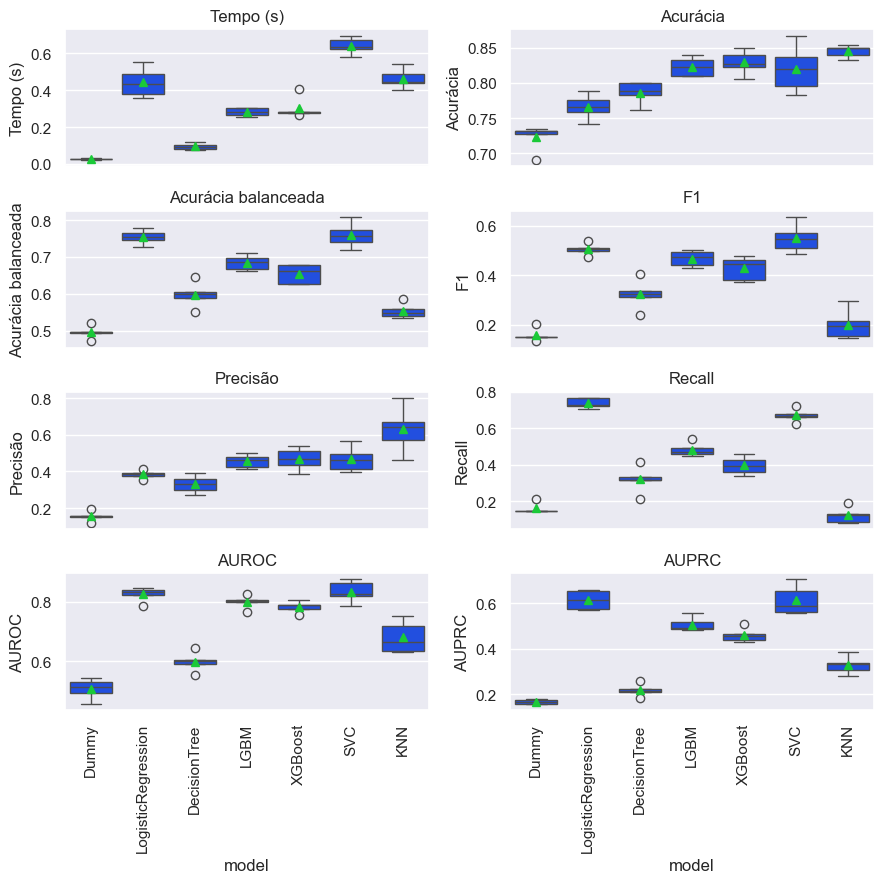

In [59]:
plot_comparar_metricas_modelos(df_resultados)

Logistic Regression e SVC apresentaram as melhores métricas de tempo e erro. 
Nesse caso seguiremos com o Logistic Regression devido aos critérios abaixo:
- Menor tempo de treinamento
- Melhor performance para os casos positivos de Desligamento (Recall)
- Mais fácil de interpretar e explicar o modelo


In [60]:
# param grid para LogisticRegression
param_grid = {
    "clf__C": [0.05, 0.1, 0.2, 0.5, 0.9],
    "clf__l1_ratio": [0.2, 0.25, 0.3,0.35, 0.4],
}


In [61]:
clf = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', solver ='saga', max_iter=10000)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessor_modelos, refit_metric="f1"
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.05, 0.1, ...], 'clf__l1_ratio': [0.2, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [62]:
grid_search.fit(X, y)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.05, 0.1, ...], 'clf__l1_ratio': [0.2, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [63]:
grid_search.best_params_

{'clf__C': 0.1, 'clf__l1_ratio': 0.4}

In [64]:
grid_search.best_score_

np.float64(0.5105036248867199)

In [65]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('ordinal_viagem', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [66]:
#classification report do melhor modelo
y_pred = grid_search.best_estimator_.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1233
           1       0.41      0.79      0.54       237

    accuracy                           0.79      1470
   macro avg       0.68      0.79      0.70      1470
weighted avg       0.87      0.79      0.81      1470



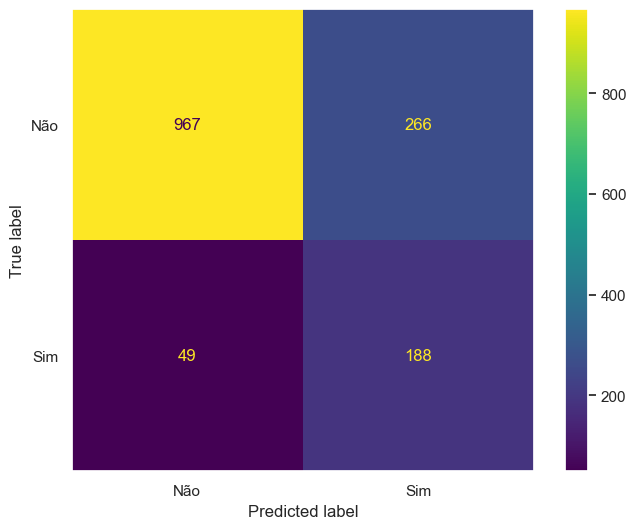

In [67]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax)
plt.grid(False)
plt.show()

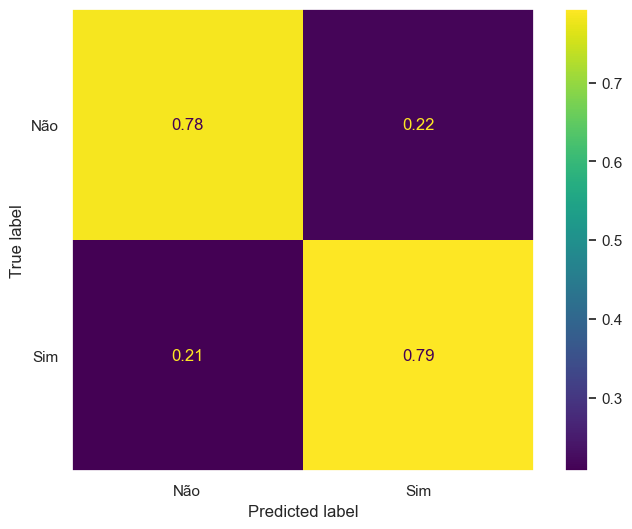

In [68]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax, normalize="true")
plt.grid(False)
plt.show()

In [69]:
coefs = grid_search.best_estimator_.named_steps['clf'].coef_[0]
colunas = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

df_coefs = dataframe_coeficientes(coefs, colunas)
df_coefs.index = [s.split('__', 1)[-1] if isinstance(s, str) else s for s in df_coefs.index]
df_coefs.sort_values(by='coeficiente', ascending=False)

,coeficiente
HoraExtra_Sim,1.342862
ViagemDeNegocios,0.683080
Departamento_Vendas,0.585201
AreaDeFormacao_Curso Técnico,0.554500
EstadoCivil_Solteiro(a),0.490675
Cargo_Técnico de Laboratório,0.404245
NumeroDeEmpresasQueTrabalhou,0.337435
AnosDesdeAUltimaPromocao,0.304624
DistanciaDeCasa,0.261945
Genero_Masculino,0.236980


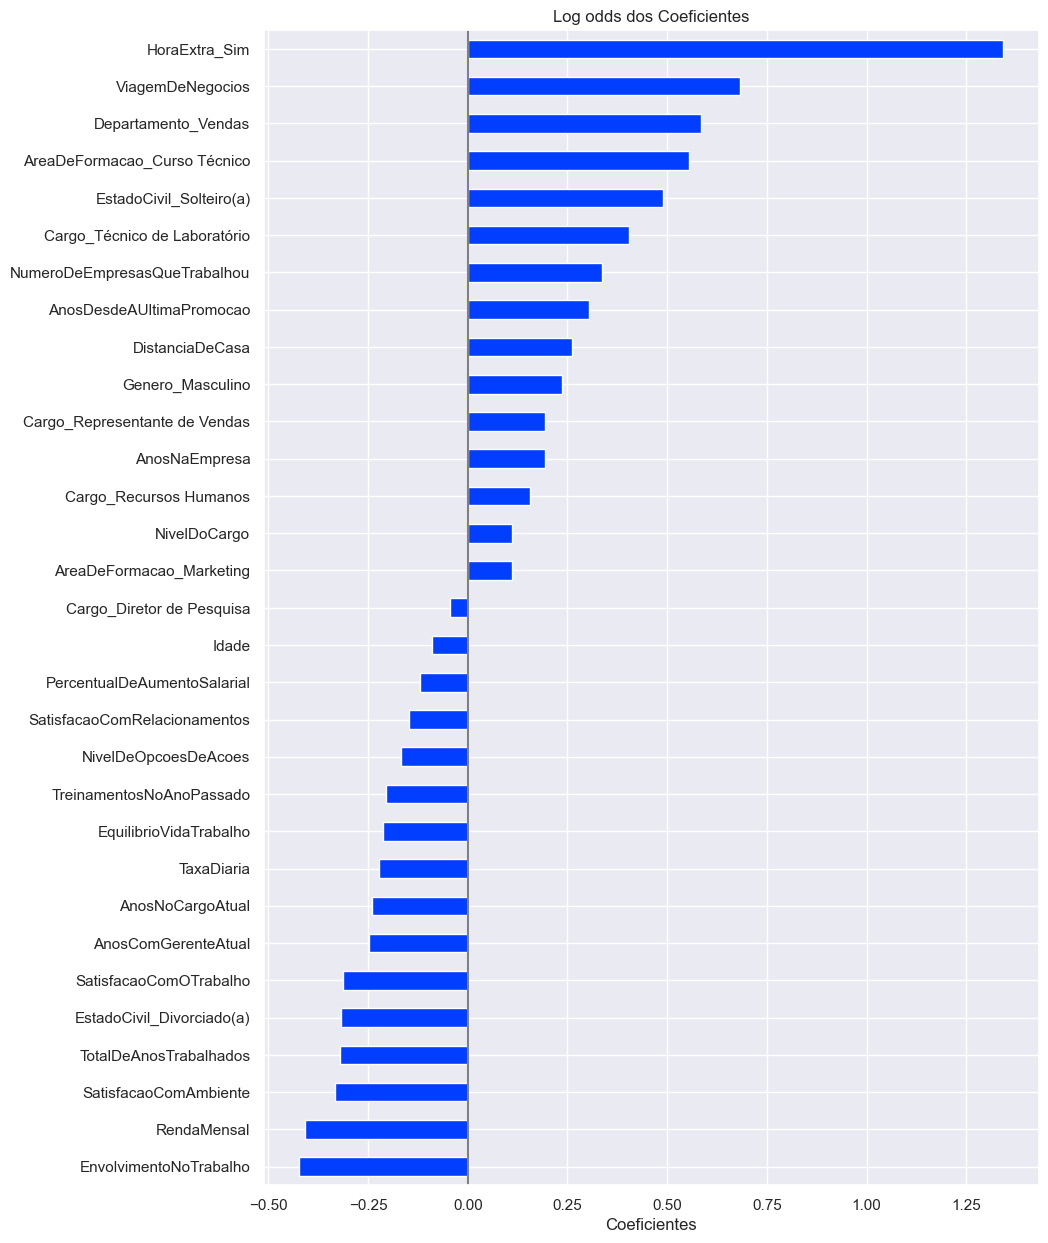

In [70]:
plot_coeficientes(df_coefs[df_coefs['coeficiente'] != 0], "Log odds dos Coeficientes")

In [71]:
#Odds ratio
df_coefs['odds_ratio'] = np.exp(df_coefs['coeficiente'])
df_coefs.sort_values(by='odds_ratio', ascending=False)

,coeficiente,odds_ratio
HoraExtra_Sim,1.342862,3.829987
ViagemDeNegocios,0.683080,1.979966
Departamento_Vendas,0.585201,1.795352
AreaDeFormacao_Curso Técnico,0.554500,1.741071
EstadoCivil_Solteiro(a),0.490675,1.633419
Cargo_Técnico de Laboratório,0.404245,1.498171
NumeroDeEmpresasQueTrabalhou,0.337435,1.401348
AnosDesdeAUltimaPromocao,0.304624,1.356115
DistanciaDeCasa,0.261945,1.299455
Genero_Masculino,0.236980,1.267416


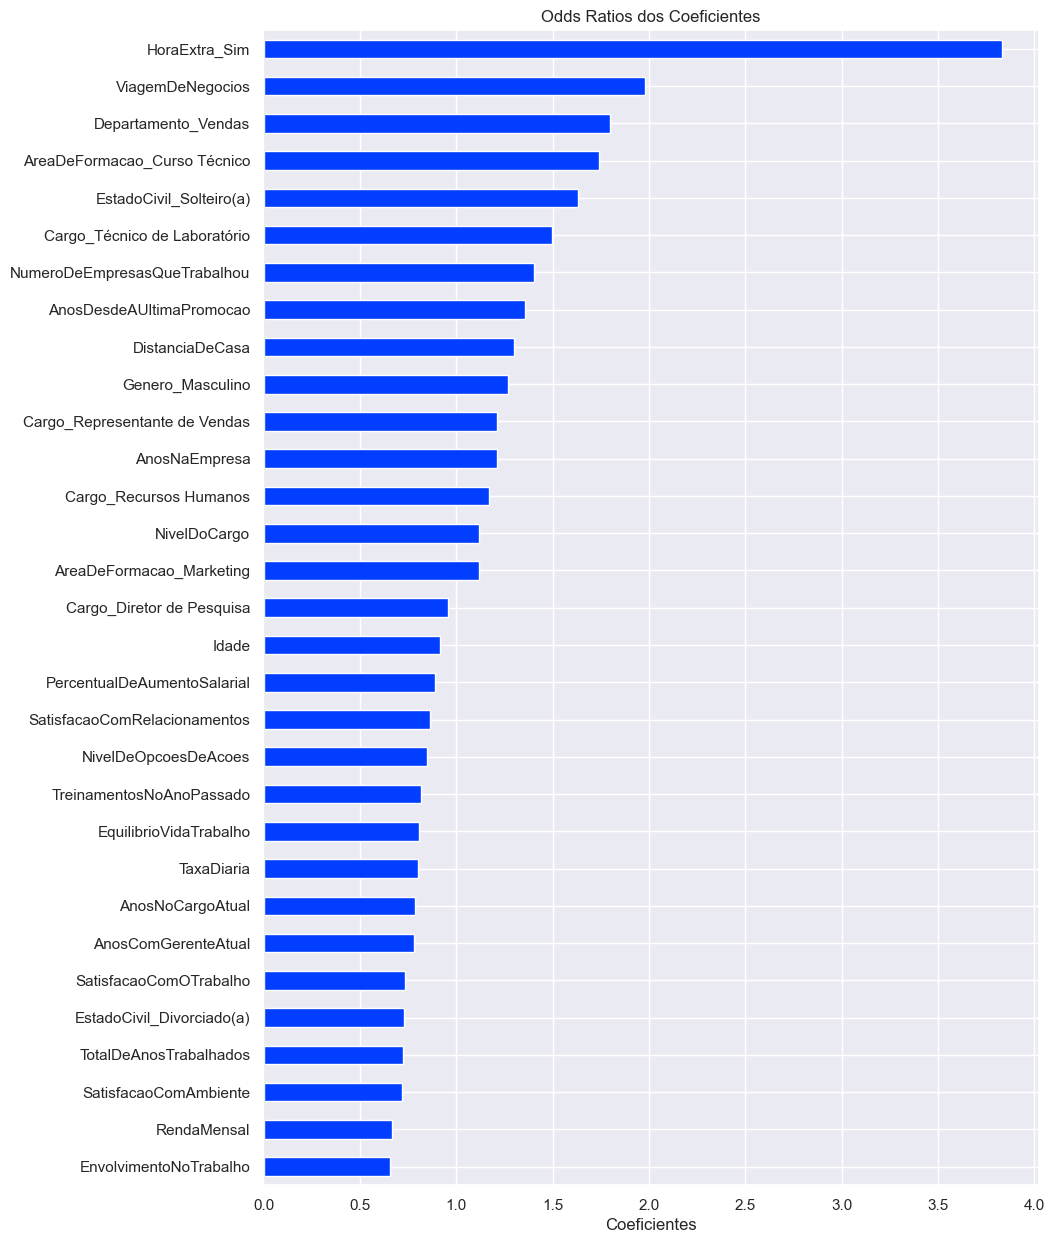

In [72]:
plot_coeficientes(df_coefs[[ "odds_ratio" ]][df_coefs['odds_ratio'] != 1], "Odds Ratios dos Coeficientes")

Insights da importância das variáveis:
- Quem faz hora extra e viaja a negócios tem maior probabilidade de desligamento
- Pessoas solteiras tem maior porbabilidade de desligamento em relação a casados e divorciados.
- Quem trabalha no departamento de vendas tem maior probabilidade de desligamento.
- Quanto maior a renda, menor a probabilidade de desligamento.

Plano de Ação:

Horas extras:
- Controle de Horas extras limitando a quantidade de horas extras por dia.
- Verificar a possibilidade de aplicação de automações em processos que exigem horas extras com frequencia.

Viagem de Negócios:
- Verificar a real necessidade de viagens, para que só ocorra quando for essencial.

Renda:
- Análisar se salário da empresa está compatível com o Mercado.

Vendas:
- Aplicar recompensas para quem atinge metas de tempo de casa para o Departamento de Vendas.
